Task 5: Moving average temperature


Write a function that calculates the 7-day moving average for temperature

Use this function on the 2025 mean temperature you collected in task 1

Make a plot showing the moving average as a line and the daily temperature as
points

In [7]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from frost_id import client_id

client_id = client_id

#Requests the daily mean air temperture for all of 2025
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
'sources': 'SN17850',
'elements': 'mean(air_temperature P1D)',
'referencetime': '2025-01-01/2025-12-31',
}

# Issue an HTTP GET request
r = requests.get(endpoint, parameters, auth=(client_id,''))
# Extract JSON data
data = r.json()

observations = data["data"]

df = pd.DataFrame(observations)

df["temperature"] = df["observations"].apply(
    lambda x: x[0]["value"]
)

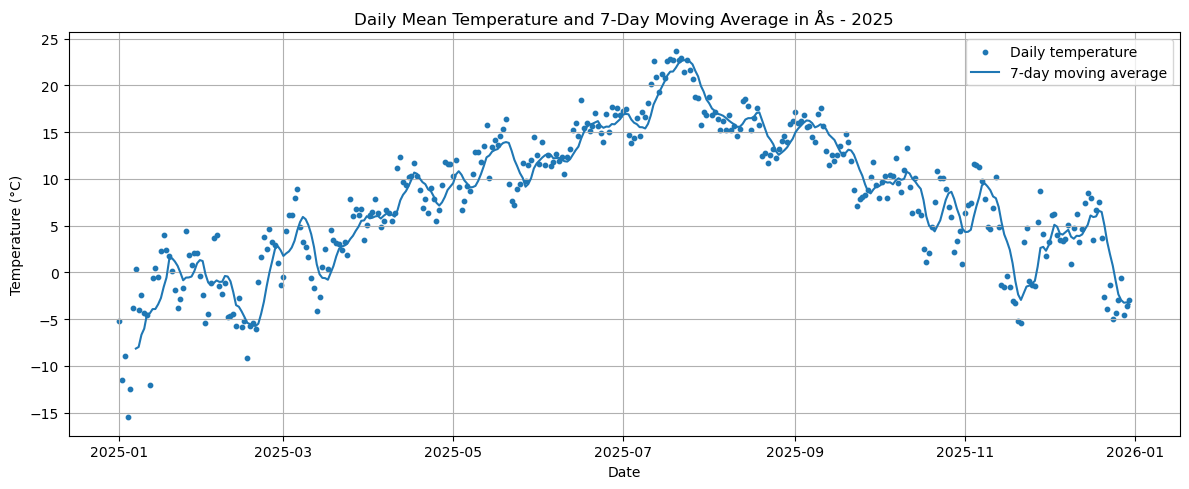

In [8]:
def moving_average(data : pd.Series, window_size : int = 7) -> pd.Series:
    """a function that calculates the 7-day moving average for temperature data"""
    
    return data.rolling(window=window_size).mean()

df["time"] = pd.to_datetime(df["referenceTime"])

df["moving_average"] = moving_average(df["temperature"])


plt.figure(figsize=(12, 5))

plt.scatter(
    df["time"],
    df["temperature"],
    label="Daily temperature",
    s=10
)

plt.plot(
    df["time"],
    df["moving_average"],
    label="7-day moving average"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Mean Temperature and 7-Day Moving Average in Ås - 2025")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()